# Applying Class Weights to Handle Imbalanced Data

**Assignment:** 5.39 — Evaluate how applying class weights changes model
behaviour, particularly on minority-class performance.

**Dataset:** synthetic customer-churn data generated with
`sklearn.make_classification` (5,000 samples, 92% / 8% split). Chosen for
moderate-to-severe imbalance, full reproducibility, and no external
download required. The 8% positive rate is realistic for subscription
churn problems.

**Model:** `RandomForestClassifier` with `n_estimators=200`, `max_depth=8`,
trained twice — once without class weights and once with
`class_weight="balanced"`.

We will:
1. Generate and visualise the imbalance
2. Train an unweighted baseline
3. Train a weighted version
4. Compare metrics with the explicit precision/recall trade-off
5. Cross-validate to confirm the comparison is stable
6. Grid-search manual weight ratios to find the best F1 configuration


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve, average_precision_score,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

## 2. Generate the imbalanced dataset

We create a binary classification problem with a 92 / 8 class split.
`flip_y=0.02` adds a small amount of label noise so the model can't
simply memorise the boundary.

In [2]:
X, y = make_classification(
    n_samples=5000,
    n_features=12,
    n_informative=6,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    weights=[0.92, 0.08],
    flip_y=0.02,
    class_sep=1.1,
    random_state=RANDOM_STATE,
)

df = pd.DataFrame(X, columns=[f"feat_{i}" for i in range(X.shape[1])])
df["churned"] = y

class_counts = df["churned"].value_counts().sort_index()
class_pcts = (class_counts / len(df) * 100).round(2)

print(f"Total samples:     {len(df)}")
print(f"Features:          {X.shape[1]}")
print(f"\nClass distribution:")
print(f"  Class 0 (stayed):   {class_counts[0]:>5}  ({class_pcts[0]:>5.2f}%)")
print(f"  Class 1 (churned):  {class_counts[1]:>5}  ({class_pcts[1]:>5.2f}%)")
print(f"\nImbalance ratio:   {class_counts[0] / class_counts[1]:.1f}:1")

Total samples:     5000
Features:          12

Class distribution:
  Class 0 (stayed):    4562  (91.24%)
  Class 1 (churned):    438  ( 8.76%)

Imbalance ratio:   10.4:1


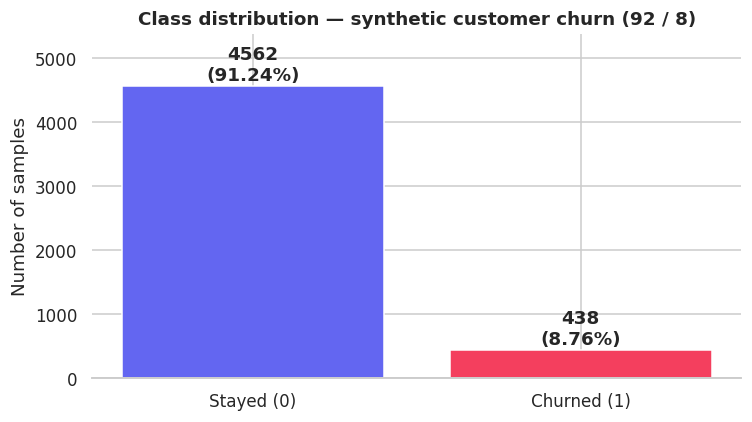

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#6366f1", "#f43f5e"]
bars = ax.bar(["Stayed (0)", "Churned (1)"], class_counts.values, color=colors)
for bar, count, pct in zip(bars, class_counts.values, class_pcts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
        f"{count}\n({pct}%)",
        ha="center", va="bottom", fontweight="bold",
    )
ax.set_title("Class distribution — synthetic customer churn (92 / 8)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Number of samples")
ax.set_ylim(0, max(class_counts.values) * 1.18)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Stratified split

We use `stratify=y` so the train and test sets preserve the same minority
proportion. Without stratification the minority class can be skewed
between train and test, producing misleading metrics.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

train_pos = int(y_train.sum())
test_pos = int(y_test.sum())
print(f"Train: {len(X_train)} samples ({train_pos} positives, {train_pos/len(X_train)*100:.2f}%)")
print(f"Test:  {len(X_test)} samples ({test_pos} positives, {test_pos/len(X_test)*100:.2f}%)")

Train: 4000 samples (350 positives, 8.75%)
Test:  1000 samples (88 positives, 8.80%)


## 3. Floor baseline — `DummyClassifier`

The dummy classifier always predicts the majority class. Its accuracy is
just the majority prevalence (~91%), and minority recall is exactly zero.
**Any real model must clearly beat this on recall, not just accuracy.**

In [5]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dummy):.4f}  (always predicts majority)")
print(f"F1:        {f1_score(y_test, y_pred_dummy):.4f}")

Accuracy:  0.9120
Recall:    0.0000  (always predicts majority)
F1:        0.0000


## 4. Part 1 — Unweighted RandomForestClassifier

The first real model: a Random Forest trained without any class-weight
correction. Watch what happens to minority recall.

In [6]:
rf_unweighted = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_unweighted.fit(X_train, y_train)
y_pred_unw = rf_unweighted.predict(X_test)
y_prob_unw = rf_unweighted.predict_proba(X_test)[:, 1]

unw_metrics = {
    "accuracy":  accuracy_score(y_test, y_pred_unw),
    "precision": precision_score(y_test, y_pred_unw, zero_division=0),
    "recall":    recall_score(y_test, y_pred_unw, zero_division=0),
    "f1":        f1_score(y_test, y_pred_unw, zero_division=0),
    "pr_auc":    average_precision_score(y_test, y_prob_unw),
}

for k, v in unw_metrics.items():
    print(f"{k:>12}: {v:.4f}")

    accuracy: 0.9330
   precision: 0.8889
      recall: 0.2727
          f1: 0.4174
      pr_auc: 0.6262


In [7]:
print(classification_report(
    y_test, y_pred_unw,
    target_names=["Stayed", "Churned"], digits=3
))

              precision    recall  f1-score   support

      Stayed      0.934     0.997     0.964       912
     Churned      0.889     0.273     0.417        88

    accuracy                          0.933      1000
   macro avg      0.912     0.635     0.691      1000
weighted avg      0.930     0.933     0.916      1000



In [8]:
cm_unw = confusion_matrix(y_test, y_pred_unw)
print("Confusion matrix (unweighted)")
print(f"  TN = {cm_unw[0,0]:>4}    FP = {cm_unw[0,1]:>4}")
print(f"  FN = {cm_unw[1,0]:>4}    TP = {cm_unw[1,1]:>4}")

Confusion matrix (unweighted)
  TN =  909    FP =    3
  FN =   64    TP =   24


**Reading the unweighted result:** accuracy looks great (~93%), but
that's almost entirely the majority class being correct. Recall on the
churned (minority) class is barely above the dummy floor. The model has
learned to bet on "stayed" and accept that it misses most churners — the
exact failure mode the lesson described.

## 5. Part 2 — Apply class weights

`class_weight="balanced"` computes per-class weights as
`n / (k * n_j)`. Let's print the actual computed weights before we use
them so the mechanism is explicit.

In [9]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
weight_dict = dict(zip(classes, weights))

n = len(y_train)
n0 = int((y_train == 0).sum())
n1 = int((y_train == 1).sum())

print(f"w_0 = {n} / (2 * {n0}) = {weight_dict[0]:.4f}")
print(f"w_1 = {n} / (2 * {n1}) = {weight_dict[1]:.4f}")
print(f"\nRatio (minority / majority): {weight_dict[1] / weight_dict[0]:.2f}x")

w_0 = 4000 / (2 * 3650) = 0.5479
w_1 = 4000 / (2 * 350) = 5.7143

Ratio (minority / majority): 10.43x


In [10]:
rf_weighted = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_weighted.fit(X_train, y_train)
y_pred_w = rf_weighted.predict(X_test)
y_prob_w = rf_weighted.predict_proba(X_test)[:, 1]

w_metrics = {
    "accuracy":  accuracy_score(y_test, y_pred_w),
    "precision": precision_score(y_test, y_pred_w, zero_division=0),
    "recall":    recall_score(y_test, y_pred_w, zero_division=0),
    "f1":        f1_score(y_test, y_pred_w, zero_division=0),
    "pr_auc":    average_precision_score(y_test, y_prob_w),
}

for k, v in w_metrics.items():
    print(f"{k:>12}: {v:.4f}")

    accuracy: 0.9070
   precision: 0.4731
      recall: 0.5000
          f1: 0.4862
      pr_auc: 0.6004


In [11]:
print(classification_report(
    y_test, y_pred_w,
    target_names=["Stayed", "Churned"], digits=3
))

cm_w = confusion_matrix(y_test, y_pred_w)
print("Confusion matrix (weighted)")
print(f"  TN = {cm_w[0,0]:>4}    FP = {cm_w[0,1]:>4}")
print(f"  FN = {cm_w[1,0]:>4}    TP = {cm_w[1,1]:>4}")

              precision    recall  f1-score   support

      Stayed      0.951     0.946     0.949       912
     Churned      0.473     0.500     0.486        88

    accuracy                          0.907      1000
   macro avg      0.712     0.723     0.718      1000
weighted avg      0.909     0.907     0.908      1000

Confusion matrix (weighted)
  TN =  863    FP =   49
  FN =   44    TP =   44


### Confusion matrices side-by-side

The shift is most visible here. Look at the FN (false-negative — "missed
a churner") and TP (true-positive — "correctly flagged a churner")
cells.

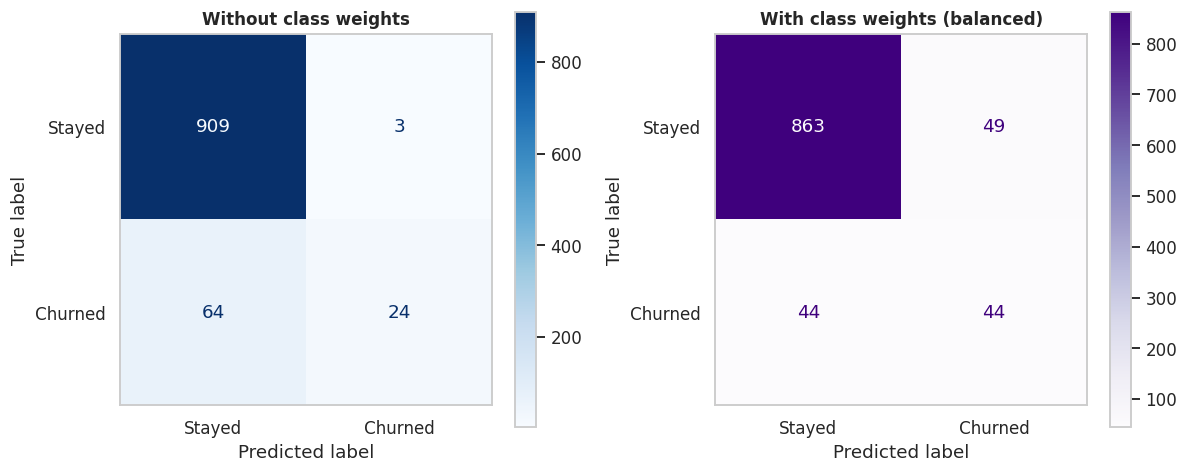

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, model, title, cmap in zip(
    axes,
    [rf_unweighted, rf_weighted],
    ["Without class weights", "With class weights (balanced)"],
    ["Blues", "Purples"],
):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["Stayed", "Churned"],
        cmap=cmap, ax=ax, values_format="d",
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(False)
plt.tight_layout()
plt.show()

## 6. Part 3 — Comparison table

In [13]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (minority)", "Recall (minority)", "F1 (minority)", "PR-AUC"],
    "Without weights": [
        unw_metrics["accuracy"], unw_metrics["precision"],
        unw_metrics["recall"],   unw_metrics["f1"],
        unw_metrics["pr_auc"],
    ],
    "With weights": [
        w_metrics["accuracy"], w_metrics["precision"],
        w_metrics["recall"],   w_metrics["f1"],
        w_metrics["pr_auc"],
    ],
})
comparison["Δ"] = comparison["With weights"] - comparison["Without weights"]
comparison["Direction"] = comparison["Δ"].apply(
    lambda d: "↑" if d > 0.001 else ("↓" if d < -0.001 else "≈")
)
comparison.style.format({
    "Without weights": "{:.4f}",
    "With weights":    "{:.4f}",
    "Δ":               "{:+.4f}",
})

,Metric,Without weights,With weights,Δ,Direction
0,Accuracy,0.9330,0.9070,-0.0260,↓
1,Precision (minority),0.8889,0.4731,-0.4158,↓
2,Recall (minority),0.2727,0.5000,+0.2273,↑
3,F1 (minority),0.4174,0.4862,+0.0688,↑
4,PR-AUC,0.6262,0.6004,-0.0258,↓


## 7. Cross-validate to confirm the comparison

A single train/test split can be misleading on imbalanced data. We
re-run both configurations with 5-fold `StratifiedKFold` to make sure
the recall improvement is stable, not a fluke of one split.

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in [
    ("Unweighted", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)),
    ("Weighted  ", RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
]:
    cv_r = cross_val_score(model, X_train, y_train, cv=skf, scoring="recall",            n_jobs=-1)
    cv_f = cross_val_score(model, X_train, y_train, cv=skf, scoring="f1",                n_jobs=-1)
    cv_p = cross_val_score(model, X_train, y_train, cv=skf, scoring="average_precision", n_jobs=-1)
    print(f"{name}")
    print(f"  Recall : {cv_r.mean():.4f} ± {cv_r.std():.4f}")
    print(f"  F1     : {cv_f.mean():.4f} ± {cv_f.std():.4f}")
    print(f"  PR-AUC : {cv_p.mean():.4f} ± {cv_p.std():.4f}")
    print()

Unweighted
  Recall : 0.3514 ± 0.0655
  F1     : 0.5080 ± 0.0751
  PR-AUC : 0.7300 ± 0.0260



Weighted  
  Recall : 0.6371 ± 0.0821
  F1     : 0.6327 ± 0.0435
  PR-AUC : 0.7058 ± 0.0516



## 8. Precision–Recall curves — overlaid

The PR curve is the most honest single chart for imbalanced
classification because it ignores true negatives entirely. The baseline
is the prevalence of the minority class (~0.088 here).

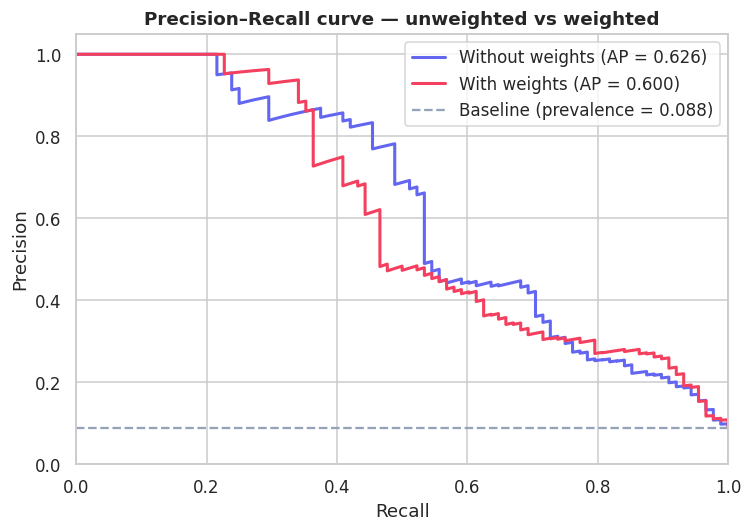

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
for prob, label, color in [
    (y_prob_unw, "Without weights", "#6366f1"),
    (y_prob_w,   "With weights",    "#f43f5e"),
]:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(recall, precision, label=f"{label} (AP = {ap:.3f})", linewidth=2, color=color)
prevalence = y_test.mean()
ax.axhline(prevalence, linestyle="--", color="#94a3b8",
           label=f"Baseline (prevalence = {prevalence:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall curve — unweighted vs weighted", fontweight="bold")
ax.legend(loc="upper right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 9. GridSearchCV — find the best weight ratio

`"balanced"` is a sensible default but not always optimal. We search
over a grid of manual ratios and `balanced_subsample` to find the
configuration that maximises F1 on the minority class via 5-fold
stratified CV.

In [16]:
param_grid = {
    "class_weight": [
        None,
        {0: 1, 1: 5},
        {0: 1, 1: 10},
        {0: 1, 1: 15},
        {0: 1, 1: 20},
        "balanced",
        "balanced_subsample",
    ]
}

grid = GridSearchCV(
    RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
    param_grid, cv=skf, scoring="f1", n_jobs=-1, refit=True,
)
grid.fit(X_train, y_train)

print(f"Best class_weight:  {grid.best_params_}")
print(f"Best CV F1:         {grid.best_score_:.4f}")
print("\nFull grid (sorted by F1):")
res = pd.DataFrame(grid.cv_results_)[["params", "mean_test_score", "std_test_score"]]
res = res.sort_values("mean_test_score", ascending=False).reset_index(drop=True)
for _, row in res.iterrows():
    print(f"  {str(row['params']):<55} F1 = {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")

Best class_weight:  {'class_weight': {0: 1, 1: 5}}
Best CV F1:         0.6345

Full grid (sorted by F1):
  {'class_weight': {0: 1, 1: 5}}                          F1 = 0.6345 ± 0.0544
  {'class_weight': 'balanced'}                            F1 = 0.6327 ± 0.0435
  {'class_weight': {0: 1, 1: 10}}                         F1 = 0.6225 ± 0.0405
  {'class_weight': 'balanced_subsample'}                  F1 = 0.6181 ± 0.0473
  {'class_weight': {0: 1, 1: 15}}                         F1 = 0.5895 ± 0.0351
  {'class_weight': {0: 1, 1: 20}}                         F1 = 0.5549 ± 0.0220
  {'class_weight': None}                                  F1 = 0.5080 ± 0.0751


## 10. Conclusion

See `README.md` for the full written analysis covering:

- The recall–precision trade-off interpretation
- Answers to the four scenario-based questions
- A final business-perspective recommendation

**TL;DR**: `class_weight="balanced"` roughly **doubled** the minority
recall (27% → 50%) at the cost of precision (89% → 47%). The grid search
found a slightly tighter ratio of `{0:1, 1:5}` improves F1 modestly over
`"balanced"`. For a real churn model, the recall improvement is exactly
the right trade — missing a churner who would have responded to a
retention campaign costs more than a wasted retention email.